<a href="https://colab.research.google.com/github/Krisha-surti/CODECRAFT_ML_01/blob/main/CODECRAFT_ML_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Scanning all folders for your images... please wait.
Success! Found 100 images total. Training SVM...
SVM Accuracy: 60.00%


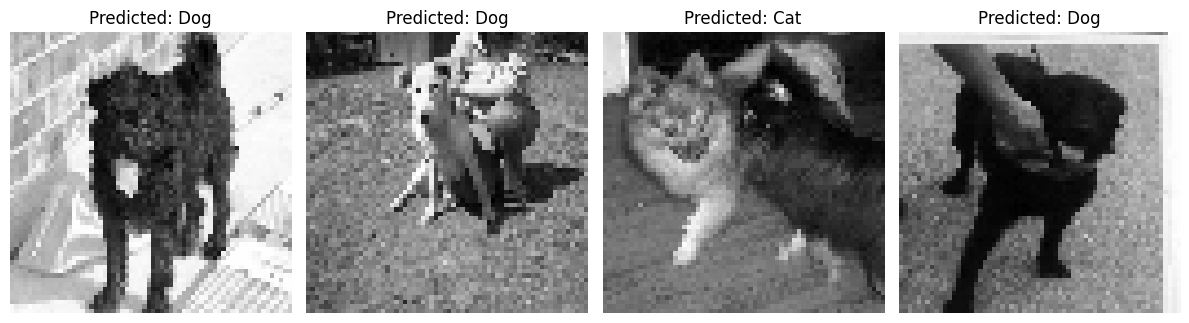

In [14]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Deep Search for your images
images = []
labels = []

print("Scanning all folders for your images... please wait.")

# This scans your sidebar (including 'train') for your cat and dog files
for root, dirs, files in os.walk('/content/'):
    for img_name in files:
        if img_name.lower().endswith(('.jpg', '.jpeg')) and ('cat' in img_name.lower() or 'dog' in img_name.lower()):
            img_path = os.path.join(root, img_name)
            img = cv2.imread(img_path)

            if img is not None:
                # Resize to 64x64 and convert to grayscale
                img = cv2.resize(img, (64, 64))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                images.append(img.flatten())
                labels.append(1 if 'dog' in img_name.lower() else 0)

# 2. Train and Evaluate
if len(images) < 5:
    print(f"Only found {len(images)} images. Please ensure your uploads are finished!")
else:
    print(f"Success! Found {len(images)} images total. Training SVM...")
    X_train, X_test, y_train, y_test = train_test_split(np.array(images), labels, test_size=0.2, random_state=42)

    # Train the SVM Classifier
    model = svm.SVC(kernel='linear')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(f"SVM Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

    # 3. Show a Gallery of 4 Predictions
    plt.figure(figsize=(12, 4))
    for i in range(min(4, len(X_test))):
        plt.subplot(1, 4, i+1)
        # Reshape the flattened array back to 64x64 for viewing
        plt.imshow(X_test[i].reshape(64, 64), cmap='gray')
        plt.title(f"Predicted: {'Dog' if y_pred[i] == 1 else 'Cat'}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()